# 04_201 · Modelos clásicos planos y jerárquicos · cuatro daños

Compara SVM lineal y regresión logística bajo tres estructuras: plano, cascada binaria y jerarquía probabilística compartida. Entrena únicamente cuatro daños gruesos; `SEGURO` es la ausencia de daño y `ACOSO_AMENAZA` fusiona acoso personal con amenaza directa.

El cuaderno usa el dataset integrado completo. La asignación train/validation/test se propaga por `video_id` desde el contrato 4:1. Los videos seguros no mapeados se asignan exclusivamente a train; ningún video de validation/test entra en entrenamiento.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image

ROOT = Path.cwd().resolve()
if ROOT.name.lower() == 'cuadernos': ROOT = ROOT.parent
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))

from scripts_auxiliares import experimentos_jerarquicos_clasicos_4 as c4
print('Proyecto:', ROOT)
print('Objetivos:', c4.TARGET_LABELS)

Proyecto: D:\trabajo_PLN\Trabajo_PLN-MIA-Grupo4
Objetivos: ['RACISMO_DISCRIMINACION', 'ACOSO_GENERO_IDENTIDAD', 'ACOSO_AMENAZA', 'CONTENIDO_SEXUAL']


## 1. Contrato de datos

Se verifican el hash del dataset unificado y el del dataset 4:1. Validation y test conservan sus videos congelados. El corpus contiene más de 100 mil `SEGURO`, pero sólo los pertenecientes a train o a videos no usados por validation/test pueden intervenir en el ajuste.

In [2]:
context = c4.load_expanded_context()
summary = c4.expanded_dataset_summary(context)
display(summary)
display(context['audit'])
assert context['audit']['targets'] == c4.TARGET_LABELS
assert context['audit']['validation_or_test_video_leakage'] is False

,split,rows,videos,safe,damage,chunk_ids_sha256
0,train,81818,2334,76874,4944,0656118657420c09e4df4229627e7b46d87274f9f01410...
1,validation,17760,448,16682,1078,01b6b5f537a540022e3ffae16963f34eb7fb958e76586a...
2,test,17666,448,16625,1041,c0c15bea2772fad7bcae8986fee3d874ce7d7de388b7bf...


{'created_at': '2026-07-28T02:01:37-05:00',
 'method': 'propagate frozen 04_2 video split; assign only unmapped SEGURO videos to train',
 'integrated_dataset': 'datos\\model_ready\\transformer_grueso\\dataset_integrado_todas_pasadas.jsonl',
 'integrated_dataset_sha256': '3f01b76d285d4cdd2a0922df1d2437a7f01abc4e05e2699c218b1f5faaba2069',
 'balanced_dataset': 'datos\\model_ready\\transformer_grueso\\dataset_balanceado_4a1_particionado.jsonl',
 'balanced_dataset_sha256': 'df2ac01183271e44b6dcfb9cb4850bd6b1ef1cd11d9fc51c881be944670ef20f',
 'integrated_rows': 117244,
 'mapped_rows': 117244,
 'unmapped_safe_rows_assigned_train': 931,
 'unmapped_videos_assigned_train': 248,
 'all_damage_retained': True,
 'validation_or_test_video_leakage': False,
 'split_counts': {'train': {'rows': 81818,
   'videos': 2334,
   'safe': 76874,
   'damage': 4944,
   'chunk_ids_sha256': '0656118657420c09e4df4229627e7b46d87274f9f01410e722f8df3440a8f9d3'},
  'validation': {'rows': 17760,
   'videos': 448,
   'safe'

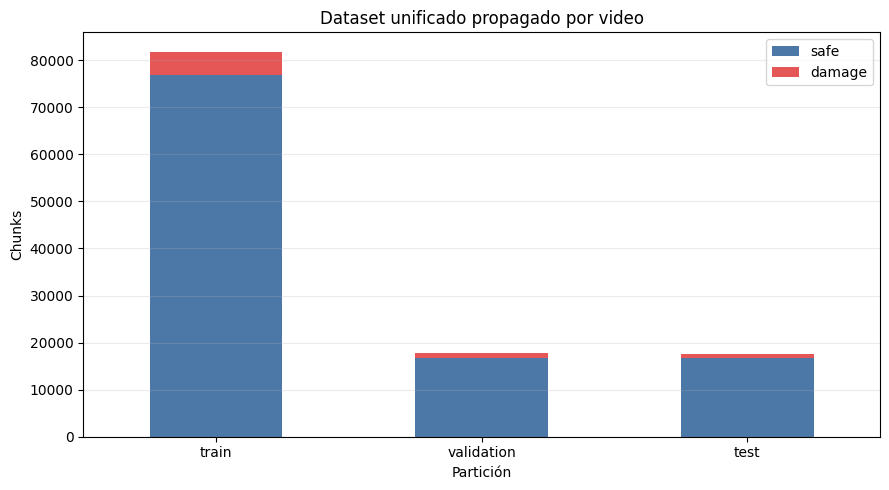

In [3]:
ax = summary.set_index('split')[['safe', 'damage']].plot.bar(stacked=True, figsize=(9, 5), color=['#4C78A8', '#E45756'])
ax.set_title('Dataset unificado propagado por video')
ax.set_ylabel('Chunks')
ax.set_xlabel('Partición')
ax.grid(axis='y', alpha=0.25)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 2. Modelos y rigor comparativo

Se reutilizan los hiperparámetros ganadores de `04_2`: SVM palabra+carácter y regresión logística. Cada familia comparte el mismo TF-IDF entre sus diseños. Los márgenes se calibran con predicciones out-of-fold de `GroupKFold` por video. Los umbrales y el ganador se determinan en validation.

La cascada multiplica la puerta `p(daño)` por cuatro cabezas entrenadas con todos los daños y negativos difíciles. La jerarquía compartida multiplica la misma puerta por las cabezas entrenadas sobre todo train. Los modelos planos proporcionan controles de la misma familia y datos. El test sólo se usa al final; las diferencias se acompañan con bootstrap pareado por video.

In [4]:
prior = c4._runtime.load_prior_hyperparameters()
display(prior['configurations'])
FORCE = False
BOOTSTRAP_REPLICATES = 1_000

{'linear_svm_word_char': {'C': 0.25, 'min_df': 1, 'max_features': 50000},
 'logistic_regression': {'C': 2.0, 'min_df': 2, 'max_features': 50000}}

## 3. Entrenamiento

La barra muestra cada cabeza calibrada. No existen épocas: SVM y regresión logística son optimizadores convexos que terminan por tolerancia o `max_iter`. Se guardan vectorizadores, cabezas calibradas, scores, umbrales, tablas, figuras e informe.

In [5]:
result = c4.run_experiment(
    force=FORCE,
    bootstrap_replicates=BOOTSTRAP_REPLICATES,
)
display(result['selection'])
display(result['training'])

{'partition': 'validation_expanded',
 'metric': 'damage_pr_auc_macro',
 'winner_key': 'svm__cascade',
 'winner_label': 'SVM lineal calibrado palabra+carácter · Cascada binaria → multietiqueta',
 'matched_flat_key': 'svm__flat',
 'paired_decision': {'rule': 'Mejora sólo si el IC95% del delta PR-AUC macro es > 0 y el límite superior del delta de tasa de falsos negativos es <= 0.',
  'status': 'diferencia_inconclusa_con_este_test',
  'replace_flat_model': False,
  'autonomous_deployment_supported': False,
  'reason_autonomy': 'El test conserva etiquetas mayormente LLM y prevalencia 4:1; se requiere un gold standard humano independiente y un piloto prospectivo.'},
 'test_used_for_selection': False}

{'linear_svm_word_char': {'family': 'linear_svm_word_char',
  'label': 'SVM lineal calibrado palabra+carácter',
  'parameters_reused_from_04_2': {'C': 0.25,
   'min_df': 1,
   'max_features': 50000},
  'feature_shape_train': [81818, 50000],
  'gate': {'description': 'svm/puerta',
   'rows': 81818,
   'positives': 4944,
   'videos': 2334,
   'calibration': 'sigmoid_on_out_of_fold_groupkfold_scores',
   'calibration_folds': 3,
   'fit_seconds': 71.33373709997977},
  'full_heads': [{'description': 'svm/cabezas completas/RACISMO_DISCRIMINACION',
    'rows': 81818,
    'positives': 1319,
    'videos': 2334,
    'calibration': 'sigmoid_on_out_of_fold_groupkfold_scores',
    'calibration_folds': 3,
    'fit_seconds': 56.818733399995835},
   {'description': 'svm/cabezas completas/ACOSO_GENERO_IDENTIDAD',
    'rows': 81818,
    'positives': 1394,
    'videos': 2334,
    'calibration': 'sigmoid_on_out_of_fold_groupkfold_scores',
    'calibration_folds': 3,
    'fit_seconds': 54.28150470001856},


## 4. Comparación de estructuras

El ganador se escoge por PR-AUC macro de validation. Una arquitectura jerárquica sólo desplaza a su plano si el intervalo pareado respalda la mejora sin empeorar falsos negativos.

,model_key,modelo,familia,diseno,split,n,exact_match,jaccard_samples,pr_auc_macro_semantic,damage_pr_auc_macro,...,damage_recall_micro,damage_f1_micro,damage_f1_macro,any_damage_precision,any_damage_recall,any_damage_f1,missed_damage_as_safe,category_recall,category_false_negatives,minimum_category_recall
0,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_expanded,17760,0.901295,0.906058,0.417959,0.275698,...,0.369581,0.327766,0.341155,0.342195,0.465677,0.394499,576,"{'RACISMO_DISCRIMINACION': 0.298932384341637, ...",887,0.298932
1,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_expanded,17666,0.903827,0.907718,0.406051,0.260830,...,0.343204,0.306441,0.320031,0.326725,0.427474,0.370370,596,"{'RACISMO_DISCRIMINACION': 0.25, 'ACOSO_GENERO...",865,0.250000
2,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_4a1,5324,0.806161,0.822048,0.566526,0.469987,...,0.369581,0.444255,0.446497,0.672922,0.465677,0.550439,576,"{'RACISMO_DISCRIMINACION': 0.298932384341637, ...",887,0.298932
3,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_4a1,5290,0.806616,0.819612,0.550870,0.450776,...,0.343204,0.415823,0.420173,0.648688,0.427474,0.515345,596,"{'RACISMO_DISCRIMINACION': 0.25, 'ACOSO_GENERO...",865,0.250000
4,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,validation_expanded,17760,0.908953,0.914837,0.409892,0.265421,...,0.368870,0.322060,0.337725,0.379902,0.431354,0.403997,613,"{'RACISMO_DISCRIMINACION': 0.3665480427046263,...",888,0.322368
5,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,test_expanded,17666,0.911185,0.916365,0.404285,0.258420,...,0.337889,0.300676,0.318530,0.364621,0.388088,0.375989,637,"{'RACISMO_DISCRIMINACION': 0.328125, 'ACOSO_GE...",872,0.265659
6,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,validation_4a1,5324,0.803531,0.823159,0.543487,0.440487,...,0.368870,0.429992,0.438620,0.712098,0.431354,0.537262,613,"{'RACISMO_DISCRIMINACION': 0.3665480427046263,...",888,0.322368
7,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,test_4a1,5290,0.800567,0.817864,0.533725,0.428504,...,0.337889,0.395029,0.407673,0.680135,0.388088,0.494190,637,"{'RACISMO_DISCRIMINACION': 0.328125, 'ACOSO_GE...",872,0.265659
8,svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,linear_svm_word_char,cascade,validation_expanded,17760,0.918637,0.923438,0.416229,0.273398,...,0.330490,0.333453,0.344141,0.412229,0.387755,0.399618,660,"{'RACISMO_DISCRIMINACION': 0.3274021352313167,...",942,0.296053
9,svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,linear_svm_word_char,cascade,test_expanded,17666,0.919620,0.923601,0.407992,0.263124,...,0.296128,0.301858,0.315775,0.390792,0.350624,0.369620,676,"{'RACISMO_DISCRIMINACION': 0.2734375, 'ACOSO_G...",927,0.224622


### Comparación cruzada sobre validation/test 4:1 comunes

,model_key,modelo,split,thresholds_selected_on_common_validation,n,exact_match,jaccard_samples,pr_auc_macro_semantic,damage_pr_auc_macro,damage_precision_micro,damage_recall_micro,damage_f1_micro,damage_f1_macro,any_damage_precision,any_damage_recall,any_damage_f1,missed_damage_as_safe
0,svm__flat,SVM lineal calibrado palabra+carácter · Plano,validation,"[0.1, 0.125, 0.125, 0.25]",5324,0.769346,0.793733,0.566526,0.469987,0.447837,0.500355,0.472642,0.482623,0.574979,0.622449,0.597773,407
1,svm__flat,SVM lineal calibrado palabra+carácter · Plano,test,"[0.1, 0.125, 0.125, 0.25]",5290,0.769943,0.790958,0.550870,0.450776,0.423338,0.473804,0.447152,0.457815,0.558288,0.588857,0.573165,428
2,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,validation,"[0.05, 0.05, 0.05, 0.1]",5324,0.796206,0.819528,0.543487,0.440487,0.476230,0.405828,0.438219,0.447631,0.695355,0.472171,0.562431,569
3,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,test,"[0.05, 0.05, 0.05, 0.1]",5290,0.796975,0.816068,0.533725,0.428504,0.448151,0.377373,0.409728,0.421850,0.664697,0.432277,0.523865,591
4,svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,validation,"[0.075, 0.1, 0.1, 0.1]",5324,0.780240,0.809886,0.557605,0.458342,0.435464,0.493959,0.462870,0.466548,0.641079,0.573284,0.605289,460
5,svm__cascade,SVM lineal calibrado palabra+carácter · Cascad...,test,"[0.075, 0.1, 0.1, 0.1]",5290,0.781853,0.807435,0.545664,0.443656,0.419398,0.476082,0.445946,0.452284,0.615385,0.537944,0.574065,481
6,logistic__flat,Regresión logística calibrada · Plano,validation,"[0.125, 0.125, 0.1, 0.22499999999999998]",5324,0.756386,0.783543,0.553262,0.453105,0.414564,0.513859,0.458902,0.467820,0.555556,0.635436,0.592817,393
7,logistic__flat,Regresión logística calibrada · Plano,test,"[0.125, 0.125, 0.1, 0.22499999999999998]",5290,0.765406,0.790154,0.540261,0.437015,0.409795,0.501898,0.451195,0.460651,0.562228,0.620557,0.589954,395
8,logistic__shared_hierarchy,Regresión logística calibrada · Jerárquico clá...,validation,"[0.075, 0.05, 0.05, 0.05]",5324,0.785875,0.811232,0.525991,0.418502,0.437313,0.416489,0.426647,0.430741,0.664533,0.481447,0.558365,559
9,logistic__shared_hierarchy,Regresión logística calibrada · Jerárquico clá...,test,"[0.075, 0.05, 0.05, 0.05]",5290,0.795085,0.814965,0.517570,0.408148,0.429636,0.394077,0.411089,0.413169,0.661932,0.447646,0.534097,575


,model_key,modelo,familia,diseno,split,categoria,positivos,recall,falsos_negativos,pr_auc
0,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_expanded,RACISMO_DISCRIMINACION,281,0.298932,197,0.299571
1,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_expanded,ACOSO_GENERO_IDENTIDAD,304,0.342105,200,0.200112
2,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_expanded,ACOSO_AMENAZA,488,0.348361,318,0.188922
3,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,validation_expanded,CONTENIDO_SEXUAL,334,0.485030,172,0.414189
4,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_expanded,RACISMO_DISCRIMINACION,256,0.250000,192,0.241473
5,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_expanded,ACOSO_GENERO_IDENTIDAD,263,0.391635,160,0.229546
6,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_expanded,ACOSO_AMENAZA,463,0.274298,336,0.167578
7,svm__flat,SVM lineal calibrado palabra+carácter · Plano,linear_svm_word_char,flat,test_expanded,CONTENIDO_SEXUAL,335,0.471642,177,0.404722
8,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,validation_expanded,RACISMO_DISCRIMINACION,281,0.366548,178,0.285291
9,svm__shared_hierarchy,SVM lineal calibrado palabra+carácter · Jerárq...,linear_svm_word_char,shared_hierarchy,validation_expanded,ACOSO_GENERO_IDENTIDAD,304,0.322368,206,0.197602


,candidate_key,flat_reference_key,metrica,plano_test,experimento_test,delta_experimento_menos_plano,ic95_inferior,ic95_superior,replicas_validas
0,svm__cascade,svm__flat,pr_auc_macro,0.260830,0.263124,0.002294,-0.006790,0.013054,1000
1,svm__cascade,svm__flat,f1_macro,0.320031,0.315775,-0.004256,-0.022528,0.013094,1000
2,svm__cascade,svm__flat,any_damage_recall,0.427474,0.350624,-0.076849,-0.102534,-0.051026,1000
3,svm__cascade,svm__flat,false_negative_rate,0.572526,0.649376,0.076849,0.051026,0.102534,1000
4,svm__shared_hierarchy,svm__flat,pr_auc_macro,0.260830,0.258420,-0.002410,-0.011444,0.009609,1000
5,svm__shared_hierarchy,svm__flat,f1_macro,0.320031,0.318530,-0.001501,-0.016305,0.014133,1000
6,svm__shared_hierarchy,svm__flat,any_damage_recall,0.427474,0.388088,-0.039385,-0.062118,-0.018909,1000
7,svm__shared_hierarchy,svm__flat,false_negative_rate,0.572526,0.611912,0.039385,0.018909,0.062118,1000
8,logistic__cascade,logistic__flat,pr_auc_macro,0.251285,0.252880,0.001595,-0.007255,0.010490,1000
9,logistic__cascade,logistic__flat,f1_macro,0.304689,0.296649,-0.008040,-0.024651,0.005398,1000


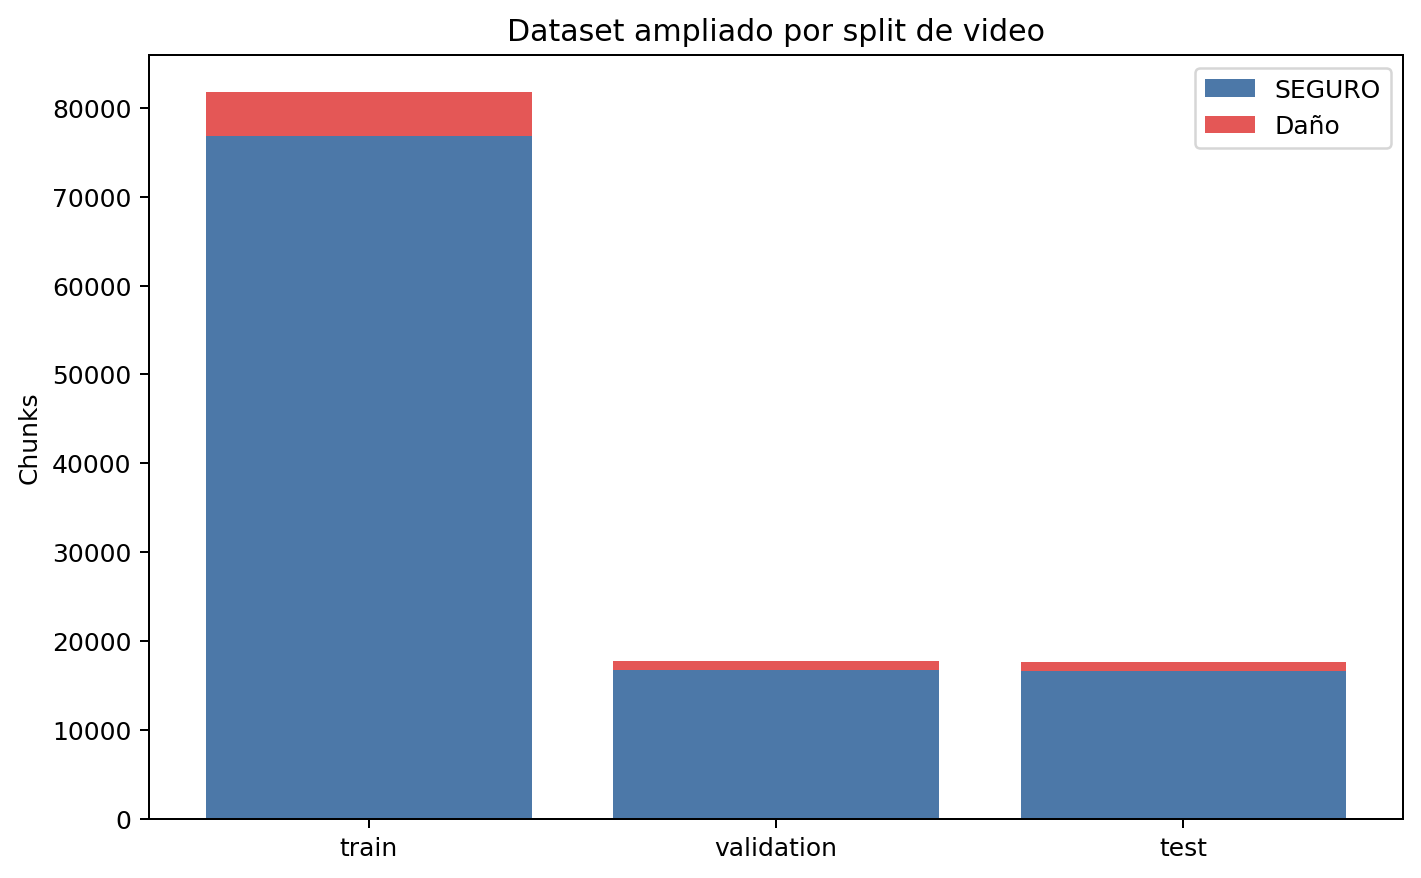

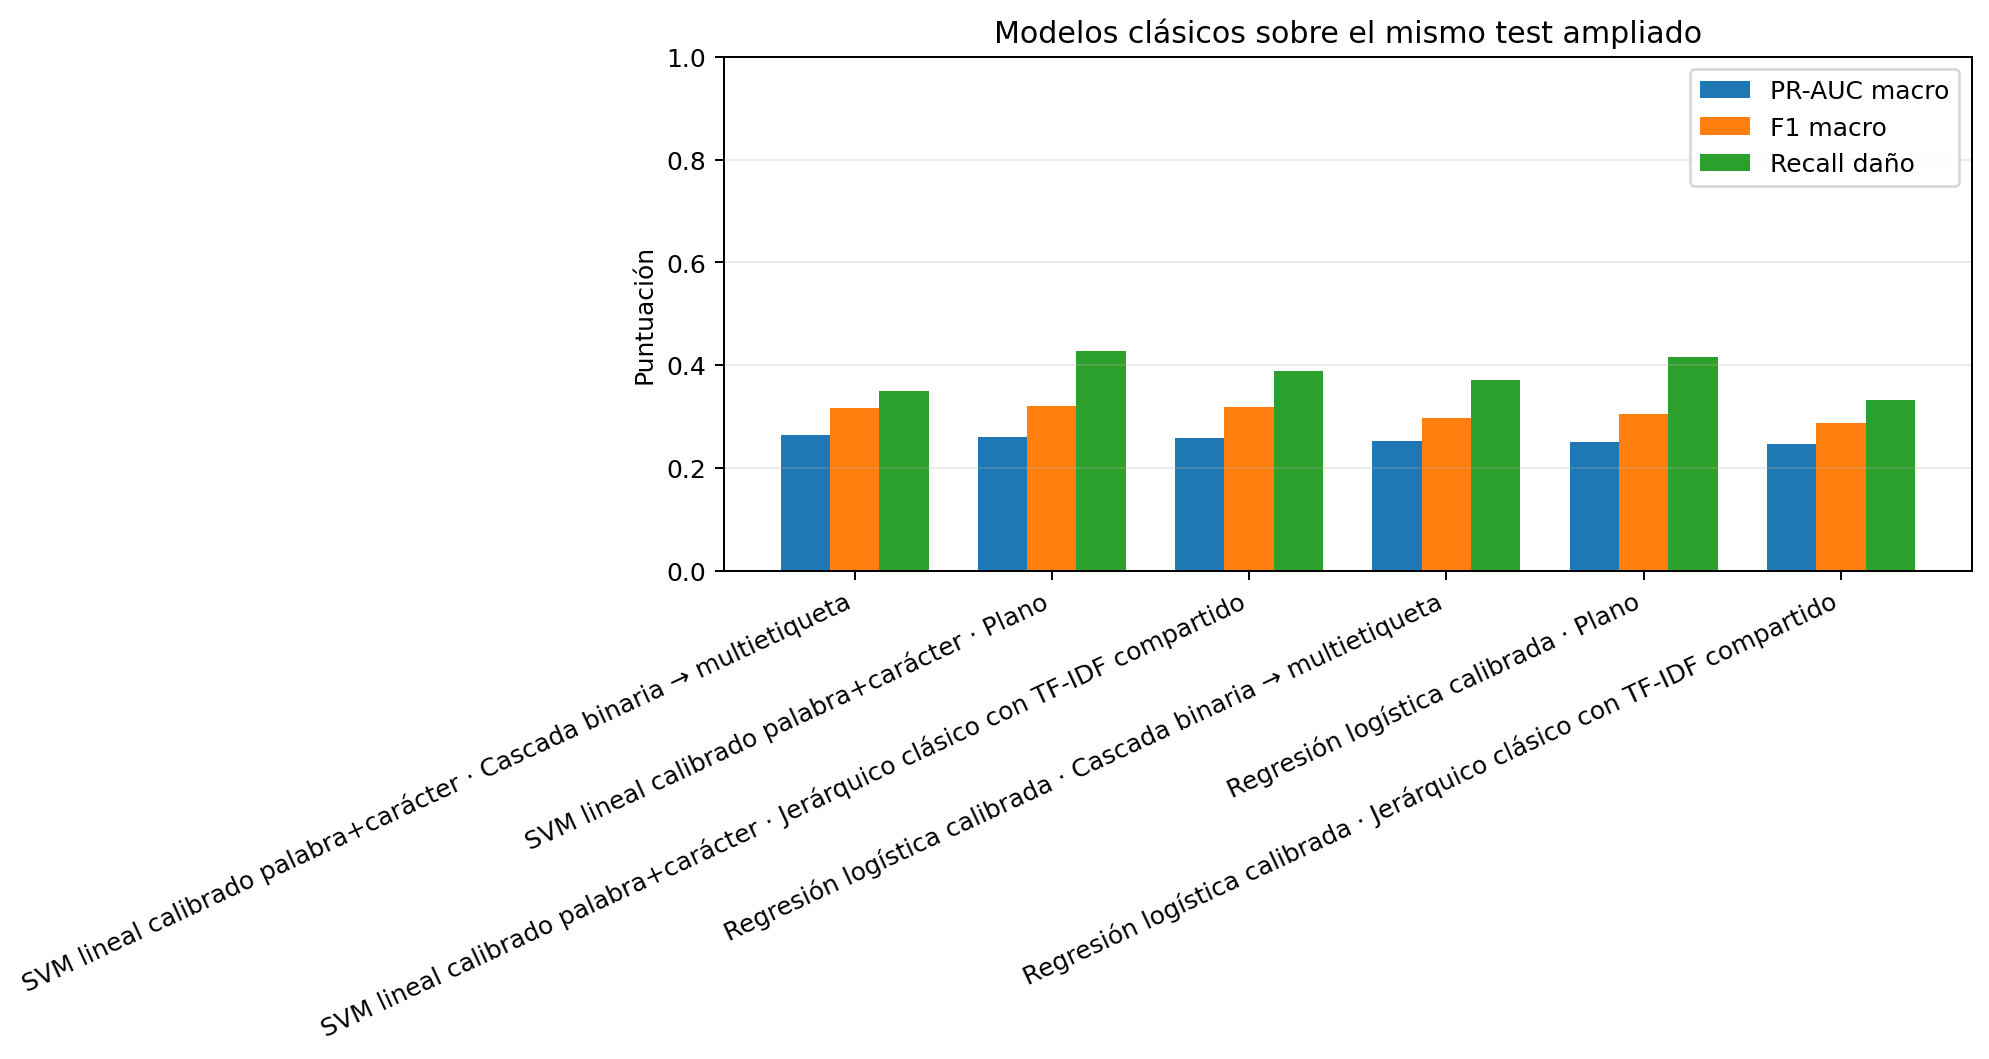

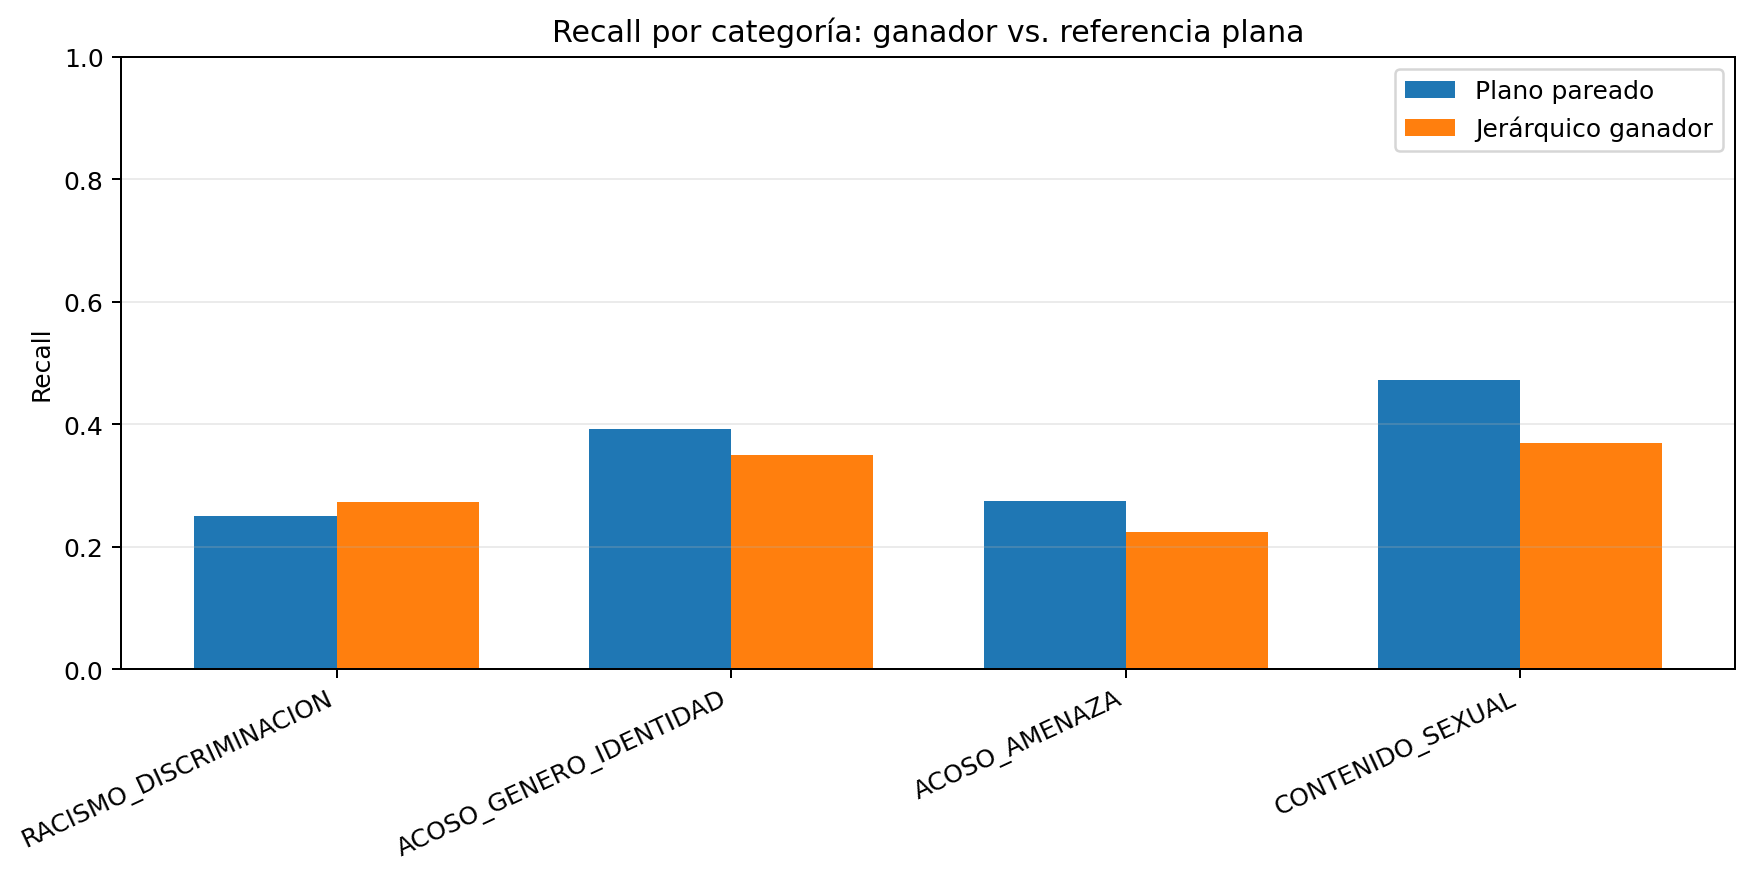

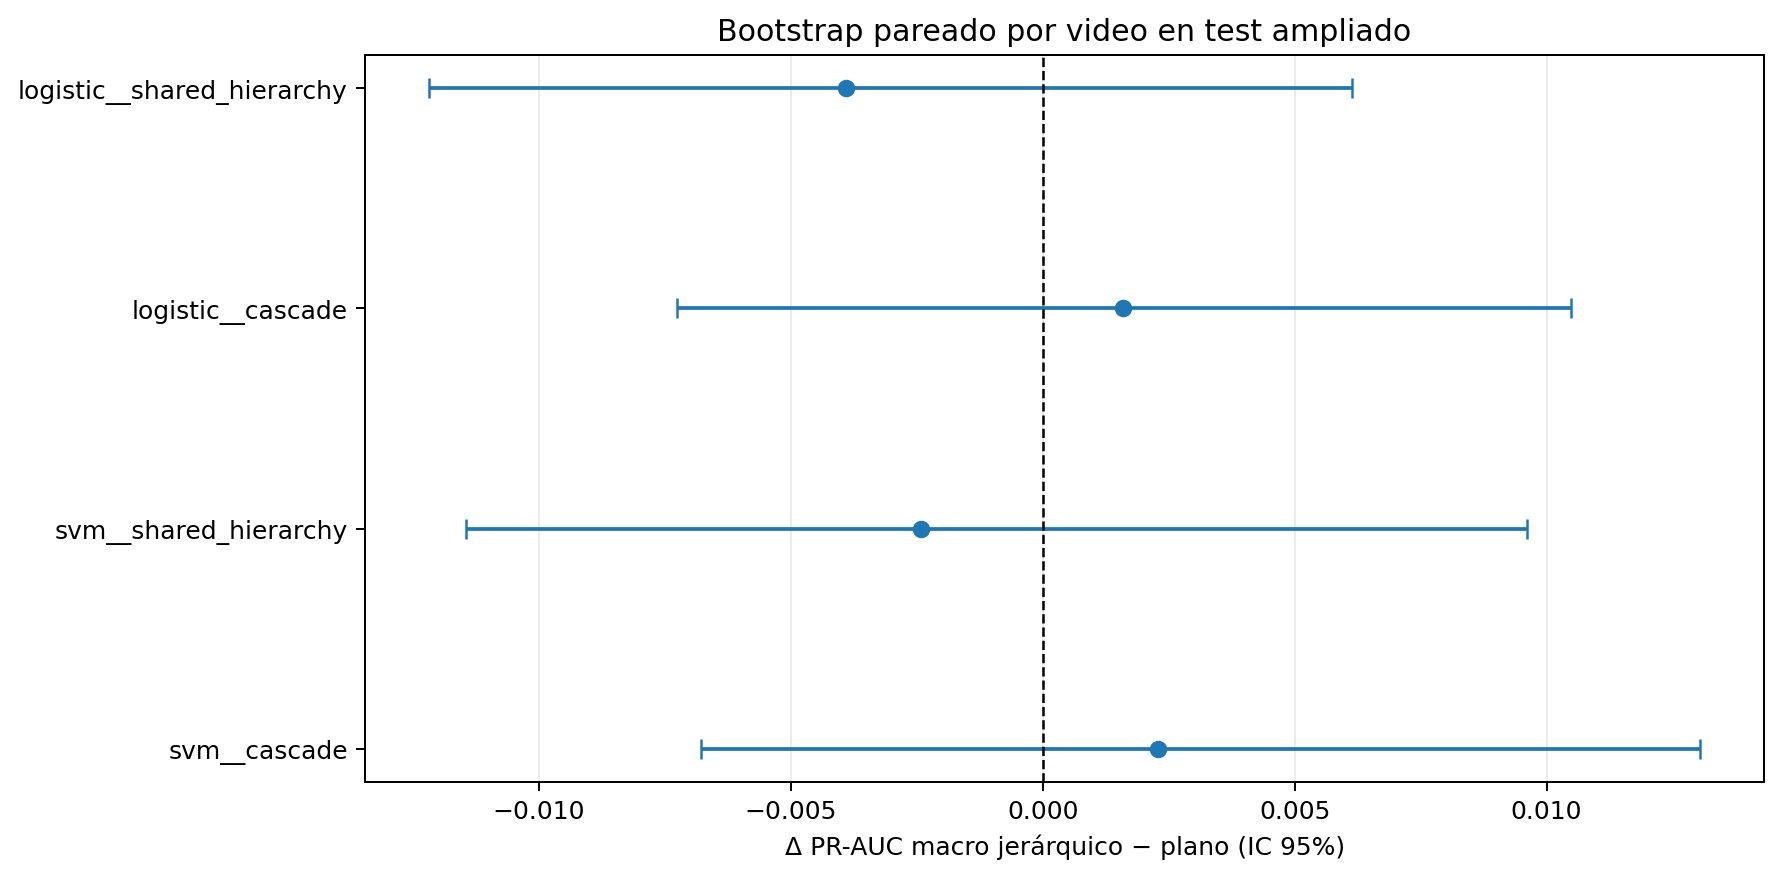

In [8]:
tables = c4.load_tables()
display(tables['comparison'])
display(Markdown('### Comparación cruzada sobre validation/test 4:1 comunes'))
display(tables['common_4a1'])
display(tables['categories'])
display(tables['bootstrap'])
figure_names = [
    'dataset_ampliado_por_split.png',
    'comparacion_global_test_ampliado.png',
    'recall_ganador_vs_plano.png',
    'bootstrap_pr_auc_jerarquicos.png',
]
for name in figure_names:
    path = c4.FIGURE_DIR / name
    if path.exists():
        display(Image(filename=str(path)))
    else:
        display(Markdown(f'> Figura opcional no encontrada: `{path.relative_to(ROOT)}`'))

In [9]:
display(Markdown(
    f'**Resultado:** `{c4.RESULT_PATH.relative_to(ROOT)}`  \n'
    f'**Informe:** `{c4.REPORT_PATH.relative_to(ROOT)}`  \n'
    f'**Modelos:** `{c4.MODEL_DIR.relative_to(ROOT)}`'
))

**Resultado:** `resultados\metricas\jerarquico_clasico_4\resultado.json`  
**Informe:** `resultados\INFORME_EXPERIMENTO_JERARQUICO_CLASICO_4.md`  
**Modelos:** `modelos\jerarquico_clasico_4`

## Referencias (APA 7)

Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research, 11*, 2079–2107. https://www.jmlr.org/papers/v11/cawley10a.html

Efron, B., & Tibshirani, R. J. (1993). *An introduction to the bootstrap*. Chapman & Hall/CRC.

Niculescu-Mizil, A., & Caruana, R. (2005). Predicting good probabilities with supervised learning. In *Proceedings of the 22nd International Conference on Machine Learning* (pp. 625–632). ACM. https://doi.org/10.1145/1102351.1102430

Saito, T., & Rehmsmeier, M. (2015). The precision-recall plot is more informative than the ROC plot when evaluating binary classifiers on imbalanced datasets. *PLOS ONE, 10*(3), e0118432. https://doi.org/10.1371/journal.pone.0118432